# 03. The Mandelbrot set

The Mandelbrot set is the set of complex parameters `c` for which the iteration

$$ z_{n+1} = z_n^2 + c, \qquad z_0 = 0 $$

stays bounded. That is the whole definition, a squaring and an addition, and yet
the boundary it draws is infinitely intricate. The render uses escape time: once
`|z|` exceeds 2 the orbit is guaranteed to diverge, so the iteration at which a
point crosses that radius shades the exterior, and points that survive to the
iteration cap are taken to be inside the set. The original code looped over every
pixel in Python; the library advances the whole complex grid at once with a mask
that retires pixels as they escape.

The escape-time grids are the heavy computation, so they are rendered in
`scripts/render_mandelbrot.py` and read back here from `artifacts/`, along with
each window's bounds. This notebook displays them.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from nldynamics.plotting import setup_style


def project_root() -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "nldynamics").exists():
            return parent
    return Path.cwd()


setup_style()
ROOT = project_root()
data = np.load(ROOT / "artifacts" / "mandelbrot.npz")
ZOOM_NAMES = ("full", "seahorse", "minibrot")

## The whole set

Start with everything. The full window spans the real axis from -2 to 0.5 and
the imaginary axis from -1.2 to 1.2, the region that contains the entire set, a
few hundred thousand pixels in all. The colour encodes how quickly each exterior
point escaped, so the black interior is the set itself: the points that never
escape.

900 x 864 = 777,600 pixels


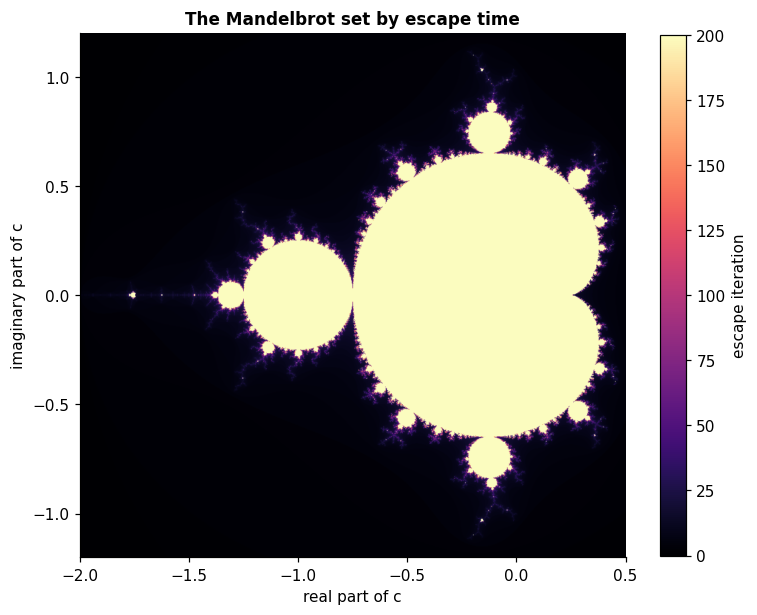

In [2]:
full = data["full"]
full_extent = tuple(data["full_extent"])
print(f"{full.shape[1]} x {full.shape[0]} = {full.size:,} pixels")

fig, ax = plt.subplots(figsize=(8, 8 * full.shape[0] / full.shape[1]))
im = ax.imshow(full, extent=full_extent, origin="lower", interpolation="bilinear")
ax.set_xlabel("real part of c")
ax.set_ylabel("imaginary part of c")
ax.set_title("The Mandelbrot set by escape time")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="escape iteration")
plt.show()

The cardioid and the bulb attached to it are the period-one and period-two
regions. The smaller bulbs around the boundary carry higher periods, and the
fine filaments connecting them are where the escape time grows steeply.

## Documented zooms

A render is fully described by its window and resolution, which the `Region`
dataclass in the library captures, so any rectangle of the plane renders the
same way. I keep three windows on file: the full view above and two deeper
zooms. The first is the seahorse valley on the neck between the cardioid and the
main bulb; the second is a miniature copy of the whole set (a "minibrot") buried
in the western filaments. The deeper windows carry a higher iteration cap,
because the escape times near the boundary grow as the window shrinks.

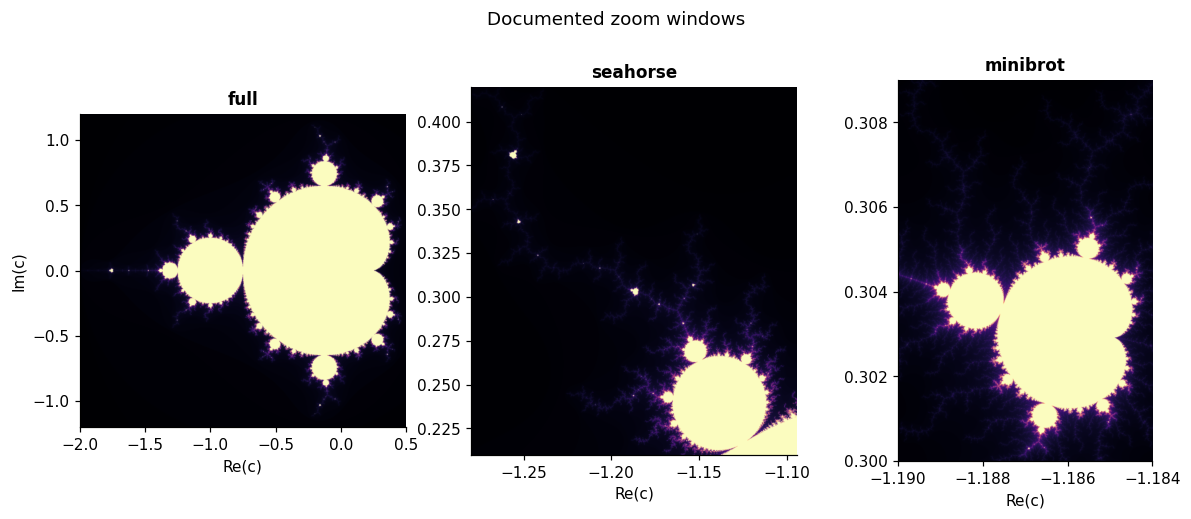

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, name in zip(axes, ZOOM_NAMES, strict=True):
    image = data[name]
    ax.imshow(image, extent=tuple(data[f"{name}_extent"]), origin="lower", interpolation="bilinear")
    ax.set_title(name)
    ax.set_xlabel("Re(c)")
    ax.grid(False)
axes[0].set_ylabel("Im(c)")
fig.suptitle("Documented zoom windows", y=1.02)
plt.show()

Each deeper window resolves structure you can't see at the scale above it: the
seahorse valley is lined with spiral tails, and the minibrot is a small copy of
the whole set, complete with its own cardioid and bulbs.

## The seahorse valley

The seahorse window enlarged on its own. The spiral tails are period structure
piling up along the boundary, the same self-similar detail that comes back at
every magnification.

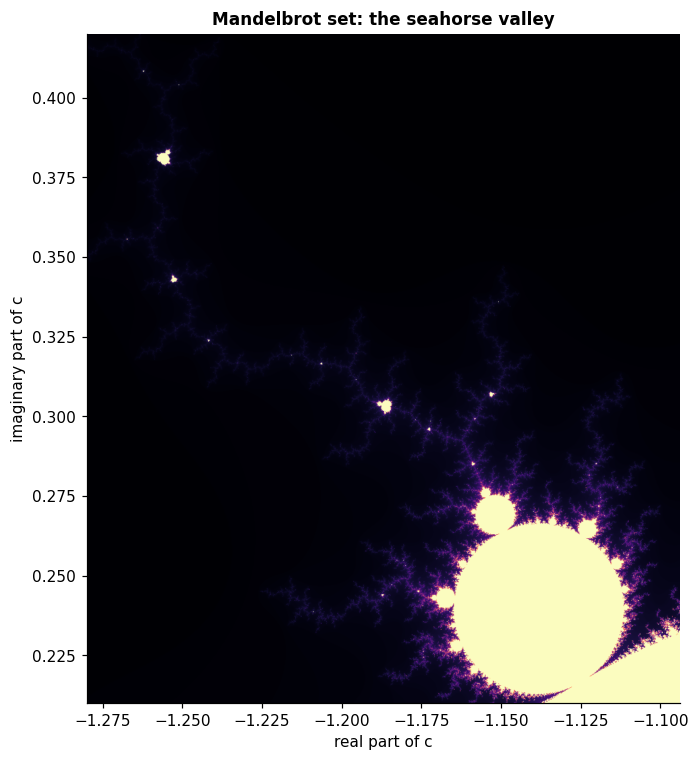

In [4]:
seahorse = data["seahorse"]
seahorse_extent = tuple(data["seahorse_extent"])
fig, ax = plt.subplots(figsize=(7, 7 * seahorse.shape[0] / seahorse.shape[1]))
ax.imshow(seahorse, extent=seahorse_extent, origin="lower", interpolation="bilinear")
ax.set_xlabel("real part of c")
ax.set_ylabel("imaginary part of c")
ax.set_title("Mandelbrot set: the seahorse valley")
ax.grid(False)
plt.show()

`scripts/render_mandelbrot.py` renders all three named windows to
`reports/figures/` for the README and writes the escape-count arrays this
notebook displays, so the script and the notebook show the same images from the
same `Region` definitions.

## Summary

- The Mandelbrot set is rendered by escape time: a point is exterior if `|z|`
  crosses 2, interior if it survives the iteration cap.
- The iteration is vectorised over the whole complex grid with an escape mask,
  replacing the original per-pixel Python loops.
- A `Region` dataclass captures a window and its resolution, so any rectangle
  renders through the same path.
- The documented zooms show the boundary staying intricate under magnification:
  spiral tails in the seahorse valley and a self-similar minibrot deep in the
  filaments.